In [131]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.sparse.linalg import spsolve
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d
from pathlib import Path
from itertools import combinations

## Data setup from other notebook
Leaves us with `final_df` that has 306(?) data points

In [97]:
def als_baseline(y, D, L, p = 0.01, niter = 10):
    """
    Asymmetric Least Squares baseline correction.
    
    Parameters:
        y    : spectrum intensity array
        lam  : smoothness (1e3 – 1e7); higher = smoother baseline
        p    : asymmetry (0.001 – 0.1); lower = baseline hugs the bottom
        niter: number of iterations
    """
    w = np.ones(L)

    for _ in range(niter):
        W = sparse.diags(w)
        Z = W + D
        z = spsolve(Z, w*y)
        w = p * (y > z) + (1 - p) * (y <= z)
    return z

In [98]:
df = pd.read_csv("02_feature_matrix_raw_T.csv", header = 0)

dataFrame = df.drop(columns=["Sample_ID", "Replica", "Origin", "Type"])

labels = (["Cotton"]*14 + ["Acrylic"]*18 + ["Nylon"]*18 + ["PP/PE"]*8 + ["Polyester"]*17 + ["Silk"]*11 + ["Wool"]*23)

ranges = [(24, 38), (50, 68), (70, 88), (88, 96), (96, 113), (125, 136), (137, 160)]
indices = np.concatenate([np.arange(s, e) for s, e in ranges])
spectrums_labeled = dataFrame.iloc[indices].reset_index(drop=True).copy()
spectrums_labeled.insert(loc = 2, column = "Labels", value = labels)
spectrums_labeled.iloc[:, :].head(20)

,Spectrum_ID,Subtype,Labels,4000.0,3999.0,3998.0,3997.0,3996.0,3995.0,3994.0,...,559.0,558.0,557.0,556.0,555.0,554.0,553.0,552.0,551.0,550.0
0,25,Cotton,Cotton,99.10,99.11,99.12,99.11,99.10,99.09,99.06,...,66.47,66.18,65.96,65.69,65.73,66.25,66.85,67.28,67.73,68.27
1,26,Cotton,Cotton,99.26,99.28,99.30,99.31,99.32,99.32,99.31,...,67.68,67.48,67.52,67.56,67.88,68.43,68.70,68.43,68.12,68.13
2,27,Cotton,Cotton,99.89,99.89,99.89,99.89,99.89,99.89,99.90,...,66.49,65.80,65.26,65.08,65.33,65.78,65.97,65.80,65.37,64.82
3,28,Cotton,Cotton,99.59,99.60,99.61,99.62,99.61,99.60,99.60,...,70.63,70.42,70.27,70.08,70.13,70.47,70.75,70.70,70.60,70.64
4,29,Cotton,Cotton,100.71,100.72,100.74,100.75,100.77,100.77,100.76,...,64.65,64.81,65.19,65.50,65.75,65.94,65.95,65.91,66.29,67.15
5,30,Cotton,Cotton,99.95,99.96,99.96,99.95,99.94,99.92,99.90,...,70.75,70.60,70.77,71.09,71.54,71.87,71.76,71.27,71.02,71.19
6,31,Cotton,Cotton,101.33,101.33,101.34,101.35,101.36,101.36,101.37,...,63.20,63.41,63.65,63.52,63.18,62.91,62.72,62.74,63.20,63.87
7,32,Cotton,Cotton,100.02,100.02,100.02,100.03,100.03,100.03,100.02,...,85.00,84.71,84.01,83.09,82.59,82.98,83.91,84.75,85.19,85.37
8,33,Cotton,Cotton,100.45,100.47,100.48,100.49,100.48,100.47,100.46,...,78.56,78.65,78.79,78.72,78.67,78.71,78.58,77.99,77.68,77.85
9,34,Cotton,Cotton,100.07,100.07,100.06,100.04,100.02,100.00,99.99,...,83.18,82.88,82.36,81.73,81.32,81.32,81.59,81.93,82.36,82.89


In [99]:
wn_common = np.arange(3999.0, 674.0, -1)

spectral_cols = [str(x) for x in wn_common]

def load_and_interpolate_csv(filepath):
    df = pd.read_csv(filepath, header=0, names=['wavenumber', 'intensity'])
    
    wn_src = df['wavenumber'].values
    ab_src = df['intensity'].values
    
    sort_idx = np.argsort(wn_src)
    wn_src = wn_src[sort_idx]
    ab_src = ab_src[sort_idx]
    
    f_interp = interp1d(wn_src, ab_src,
                        kind='cubic',
                        bounds_error=False,
                        fill_value=np.nan)
    
    interpolated = f_interp(wn_common)
    
    if np.any(np.isnan(interpolated)):
        nans = np.isnan(interpolated)
        interpolated[nans] = np.interp(
            np.where(nans)[0],
            np.where(~nans)[0],
            interpolated[~nans]
        )
    
    return interpolated


data_root = Path(".")

rows = []

for folder in data_root.iterdir():
    if not folder.is_dir():
        continue
    if folder.name == "KARLILE_excel_27032019":
        continue
    
    for csv_file in folder.glob("*.CSV"):
        spectrum = load_and_interpolate_csv(csv_file)

        name = csv_file.stem

        label, spectrum_id = name.rsplit("_", 1)

        if label == "PET_fibers":
            label = "Polyester"
        if label == "Polypropylene":
            label = "PP/PE"
        if label == "wool":
            label = "Wool"   
        if label == "Nylon_fibers":
            label = "Nylon" 
        
        row = {'Spectrum_ID': spectrum_id, 'Labels': label}
        row.update(dict(zip(spectral_cols, spectrum)))
        rows.append(row)

df_d2 = pd.DataFrame(rows)

print(df_d2.shape)
df_d2.iloc[0:, :].head(10)

(197, 3327)


,Spectrum_ID,Labels,3999.0,3998.0,3997.0,3996.0,3995.0,3994.0,3993.0,3992.0,...,684.0,683.0,682.0,681.0,680.0,679.0,678.0,677.0,676.0,675.0
0,16,Wool,-0.216042,-0.216035,-0.216063,-0.216130,-0.216242,-0.216406,-0.216626,-0.216908,...,0.096538,0.097353,0.097703,0.097660,0.097457,0.097331,0.097519,0.098257,0.099780,0.102325
1,17,Wool,0.056792,0.056810,0.056768,0.056669,0.056513,0.056305,0.056045,0.055737,...,0.258814,0.258886,0.258724,0.258466,0.258351,0.258623,0.259521,0.261288,0.264164,0.268392
2,9,Wool,-0.222252,-0.222278,-0.222263,-0.222236,-0.222225,-0.222256,-0.222358,-0.222557,...,0.119036,0.119242,0.119287,0.119212,0.119135,0.119174,0.119449,0.120076,0.121176,0.122867
3,15,Wool,-0.291844,-0.291850,-0.291861,-0.291895,-0.291969,-0.292100,-0.292305,-0.292601,...,-0.022079,-0.021984,-0.022126,-0.022386,-0.022503,-0.022215,-0.021261,-0.019377,-0.016303,-0.011775
4,14,Wool,-0.164465,-0.164453,-0.164487,-0.164560,-0.164671,-0.164813,-0.164985,-0.165181,...,0.154280,0.154891,0.155117,0.155025,0.154870,0.154907,0.155391,0.156578,0.158724,0.162084
5,8,Wool,-0.421697,-0.421738,-0.421714,-0.421657,-0.421599,-0.421569,-0.421599,-0.421721,...,-0.039490,-0.039560,-0.039638,-0.039728,-0.039747,-0.039616,-0.039251,-0.038571,-0.037496,-0.035942
6,10,Wool,-0.311972,-0.311984,-0.311974,-0.311964,-0.311976,-0.312032,-0.312153,-0.312361,...,-0.123279,-0.123439,-0.123586,-0.123696,-0.123706,-0.123553,-0.123175,-0.122508,-0.121490,-0.120059
7,11,Wool,-0.155364,-0.155391,-0.155364,-0.155311,-0.155264,-0.155252,-0.155306,-0.155457,...,0.073697,0.073901,0.074007,0.074005,0.073954,0.073914,0.073946,0.074111,0.074469,0.075079
8,13,Wool,-0.261575,-0.261578,-0.261585,-0.261611,-0.261671,-0.261778,-0.261948,-0.262194,...,0.009401,0.009427,0.009315,0.009128,0.009050,0.009270,0.009972,0.011344,0.013574,0.016846
9,12,Wool,-0.181455,-0.181471,-0.181482,-0.181503,-0.181551,-0.181640,-0.181787,-0.182007,...,0.191776,0.191852,0.191713,0.191471,0.191352,0.191585,0.192396,0.194014,0.196666,0.200580


In [100]:
spectrums = spectrums_labeled.drop(columns=["Subtype"])

L = spectrums.iloc[:, 3:3328].shape[1]
D = sparse.diags([1, -2, 1], [0, 1, 2], shape=(L - 2, L))
D = 1e5 * D.T @ D 

corrected = spectrums.copy()

for i in range(spectrums.shape[0]):
    y = spectrums.iloc[i, 3:3328].values.astype(float)
    baseline = als_baseline(y, D, L)
    corrected.iloc[i, 3:3328] = y - baseline

meta = corrected.iloc[:, :2].reset_index(drop=True)
values = corrected.iloc[:, 3:3328].astype(float)
    
normalized = values.copy()

for i in range(values.shape[0]):
    row = values.iloc[i].values
    normalized.iloc[i, :] = (row - row.mean())/row.std()

smoothed = normalized.copy()

for i in range(normalized.shape[0]):
    smoothed.iloc[i, :] = savgol_filter(normalized.iloc[i, :], window_length=9, polyorder=3)

final_df_1 = pd.concat([meta, smoothed], axis=1)

print(final_df_1.shape)
final_df_1.iloc[:, :].head(20)

/opt/anaconda3/lib/python3.11/site-packages/scipy/sparse/_construct.py:543: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
Note: In Python 3.11, this warning can be generated by a call of scipy.sparse.diags(), but the code indicated in the warning message will refer to an internal call of scipy.sparse.diags_array(). If that happens, check your code for the use of diags().
  A = diags_array(diagonals, offsets=offsets, shape=shape, dtype=dtype)
/var/folders/1m/_kc705z91wn9rgljb4jv9m5c0000gp/T/ipykernel_76635/1367918231.py:16: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(Z, w*y)


(109, 3327)


,Spectrum_ID,Labels,3999.0,3998.0,3997.0,3996.0,3995.0,3994.0,3993.0,3992.0,...,684.0,683.0,682.0,681.0,680.0,679.0,678.0,677.0,676.0,675.0
0,25,Cotton,-0.589431,-0.583491,-0.585809,-0.593964,-0.605536,-0.617946,-0.627697,-0.633485,...,-0.001050,-0.014039,-0.043559,-0.090381,-0.154960,-0.242933,-0.350740,-0.477703,-0.623266,-0.786871
1,26,Cotton,-0.554183,-0.541143,-0.533607,-0.530690,-0.531509,-0.535060,-0.540494,-0.546764,...,0.519866,0.494692,0.438794,0.344631,0.200871,-0.001833,-0.260377,-0.565495,-0.912743,-1.297676
2,27,Cotton,-0.576121,-0.576430,-0.576432,-0.575790,-0.574169,-0.570710,-0.565197,-0.558863,...,-0.447825,-0.420701,-0.392673,-0.363106,-0.332719,-0.305207,-0.279574,-0.261360,-0.253823,-0.260220
3,28,Cotton,-0.601464,-0.594101,-0.591870,-0.593198,-0.596515,-0.599431,-0.601514,-0.600325,...,0.021621,0.025172,0.003112,-0.046516,-0.121213,-0.225664,-0.354369,-0.499100,-0.654319,-0.814492
4,29,Cotton,-0.596008,-0.582916,-0.574488,-0.570278,-0.569844,-0.573096,-0.579014,-0.587144,...,0.054210,0.056583,0.041850,0.004182,-0.060275,-0.150235,-0.262368,-0.383451,-0.505433,-0.620266
5,30,Cotton,-0.591959,-0.594487,-0.601510,-0.611844,-0.624307,-0.637513,-0.650889,-0.663657,...,-0.122792,-0.130021,-0.130374,-0.136052,-0.169056,-0.244764,-0.367873,-0.518039,-0.687535,-0.868637
6,31,Cotton,-0.623636,-0.617032,-0.611487,-0.607000,-0.603571,-0.600209,-0.599309,-0.600313,...,0.021322,-0.006999,-0.045469,-0.091708,-0.147727,-0.225148,-0.325771,-0.455509,-0.619242,-0.821848
7,32,Cotton,-0.539040,-0.533678,-0.531087,-0.531212,-0.533995,-0.537068,-0.546551,-0.561239,...,0.215214,0.152367,0.079687,0.006958,-0.062302,-0.131947,-0.214292,-0.319515,-0.456274,-0.633230
8,33,Cotton,-0.567452,-0.550339,-0.547106,-0.553409,-0.564903,-0.574342,-0.581314,-0.581660,...,-0.082974,-0.101992,-0.150574,-0.219196,-0.298141,-0.386205,-0.480079,-0.599502,-0.754634,-0.955637
9,34,Cotton,-0.541409,-0.546789,-0.553039,-0.559373,-0.565004,-0.568794,-0.569545,-0.568212,...,4.181939,4.211716,4.232154,4.248411,4.263655,4.277513,4.290191,4.302231,4.314129,4.326380


In [102]:
L = df_d2.iloc[:, 2:].shape[1]
D = sparse.diags([1, -2, 1], [0, 1, 2], shape=(L - 2, L))
D = 1e5 * D.T @ D 

corrected_2 = df_d2.copy()

for i in range(df_d2.shape[0]):
    y = df_d2.iloc[i, 2:].values.astype(float)
    baseline = als_baseline(y, D, L)
    corrected_2.iloc[i, 2:] = y - baseline

meta_2 = corrected_2.iloc[:, :2].reset_index(drop=True)
values_2 = corrected_2.iloc[:, 2:].astype(float)
    
normalized_2 = values_2.copy()

for i in range(values_2.shape[0]):
    row = values_2.iloc[i].values
    normalized_2.iloc[i, :] = (row - row.mean())/row.std()

smoothed_2 = normalized_2.copy()

for i in range(normalized_2.shape[0]):
    smoothed_2.iloc[i, :] = savgol_filter(normalized_2.iloc[i, :], window_length=9, polyorder=3)

final_df_2 = pd.concat([meta_2, smoothed_2], axis=1)

print(final_df_2.shape)
final_df_2.iloc[:, :].head(20)

/opt/anaconda3/lib/python3.11/site-packages/scipy/sparse/_construct.py:543: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
Note: In Python 3.11, this warning can be generated by a call of scipy.sparse.diags(), but the code indicated in the warning message will refer to an internal call of scipy.sparse.diags_array(). If that happens, check your code for the use of diags().
  A = diags_array(diagonals, offsets=offsets, shape=shape, dtype=dtype)
/var/folders/1m/_kc705z91wn9rgljb4jv9m5c0000gp/T/ipykernel_76635/1367918231.py:16: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(Z, w*y)


(197, 3327)


,Spectrum_ID,Labels,3999.0,3998.0,3997.0,3996.0,3995.0,3994.0,3993.0,3992.0,...,684.0,683.0,682.0,681.0,680.0,679.0,678.0,677.0,676.0,675.0
0,16,Wool,-0.527601,-0.522800,-0.522208,-0.526358,-0.535781,-0.551718,-0.574817,-0.604520,...,-0.348804,-0.360645,-0.412133,-0.501626,-0.613334,-0.721319,-0.794754,-0.804554,-0.723383,-0.523906
1,17,Wool,-0.561656,-0.553441,-0.553276,-0.560750,-0.575454,-0.597641,-0.627010,-0.662126,...,-0.483750,-0.558275,-0.653861,-0.756598,-0.843332,-0.883739,-0.844018,-0.691606,-0.395183,0.076571
2,9,Wool,-0.595052,-0.594095,-0.590112,-0.585252,-0.581669,-0.582305,-0.589443,-0.604012,...,-0.474601,-0.517313,-0.568536,-0.627118,-0.687110,-0.739207,-0.772485,-0.776596,-0.741770,-0.658239
3,15,Wool,-0.521421,-0.517666,-0.515329,-0.516886,-0.524811,-0.543164,-0.574683,-0.619397,...,-0.396652,-0.496369,-0.616601,-0.746551,-0.858363,-0.912074,-0.861881,-0.664061,-0.276980,0.340998
4,14,Wool,-0.596816,-0.592262,-0.594345,-0.602419,-0.615841,-0.634435,-0.657634,-0.684067,...,-0.435041,-0.485856,-0.571097,-0.691706,-0.827080,-0.941952,-0.993996,-0.943401,-0.752879,-0.385142
5,8,Wool,-0.636162,-0.634560,-0.627402,-0.617383,-0.607194,-0.600390,-0.599807,-0.606807,...,-0.638282,-0.679909,-0.715765,-0.749542,-0.778481,-0.795754,-0.792584,-0.760888,-0.693280,-0.582373
6,10,Wool,-0.562045,-0.560066,-0.553675,-0.547846,-0.547554,-0.560539,-0.592230,-0.643339,...,-0.313326,-0.475632,-0.626900,-0.765035,-0.880084,-0.957096,-0.978715,-0.928442,-0.790634,-0.549650
7,11,Wool,-0.655032,-0.654703,-0.648090,-0.638672,-0.629928,-0.626613,-0.632416,-0.648849,...,-0.478331,-0.520914,-0.567867,-0.624501,-0.688788,-0.754043,-0.811344,-0.852566,-0.870384,-0.857472
8,13,Wool,-0.608422,-0.605641,-0.603800,-0.604535,-0.609481,-0.621471,-0.642337,-0.671872,...,-0.470880,-0.564541,-0.662939,-0.764583,-0.855514,-0.913444,-0.912082,-0.826561,-0.633447,-0.309306
9,12,Wool,-0.613295,-0.610271,-0.606921,-0.604917,-0.605932,-0.612478,-0.626363,-0.647972,...,-0.368175,-0.477088,-0.600376,-0.730151,-0.848426,-0.930099,-0.946632,-0.870708,-0.676240,-0.337140


In [103]:
final_df = pd.concat([final_df_1, final_df_2], ignore_index=True)
print(final_df.info())
final_df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306 entries, 0 to 305
Columns: 3327 entries, Spectrum_ID to 675.0
dtypes: float64(3325), object(2)
memory usage: 7.8+ MB
None


,Spectrum_ID,Labels,3999.0,3998.0,3997.0,3996.0,3995.0,3994.0,3993.0,3992.0,...,684.0,683.0,682.0,681.0,680.0,679.0,678.0,677.0,676.0,675.0
0,25,Cotton,-0.589431,-0.583491,-0.585809,-0.593964,-0.605536,-0.617946,-0.627697,-0.633485,...,-0.001050,-0.014039,-0.043559,-0.090381,-0.154960,-0.242933,-0.350740,-0.477703,-0.623266,-0.786871
1,26,Cotton,-0.554183,-0.541143,-0.533607,-0.530690,-0.531509,-0.535060,-0.540494,-0.546764,...,0.519866,0.494692,0.438794,0.344631,0.200871,-0.001833,-0.260377,-0.565495,-0.912743,-1.297676
2,27,Cotton,-0.576121,-0.576430,-0.576432,-0.575790,-0.574169,-0.570710,-0.565197,-0.558863,...,-0.447825,-0.420701,-0.392673,-0.363106,-0.332719,-0.305207,-0.279574,-0.261360,-0.253823,-0.260220
3,28,Cotton,-0.601464,-0.594101,-0.591870,-0.593198,-0.596515,-0.599431,-0.601514,-0.600325,...,0.021621,0.025172,0.003112,-0.046516,-0.121213,-0.225664,-0.354369,-0.499100,-0.654319,-0.814492
4,29,Cotton,-0.596008,-0.582916,-0.574488,-0.570278,-0.569844,-0.573096,-0.579014,-0.587144,...,0.054210,0.056583,0.041850,0.004182,-0.060275,-0.150235,-0.262368,-0.383451,-0.505433,-0.620266
5,30,Cotton,-0.591959,-0.594487,-0.601510,-0.611844,-0.624307,-0.637513,-0.650889,-0.663657,...,-0.122792,-0.130021,-0.130374,-0.136052,-0.169056,-0.244764,-0.367873,-0.518039,-0.687535,-0.868637
6,31,Cotton,-0.623636,-0.617032,-0.611487,-0.607000,-0.603571,-0.600209,-0.599309,-0.600313,...,0.021322,-0.006999,-0.045469,-0.091708,-0.147727,-0.225148,-0.325771,-0.455509,-0.619242,-0.821848
7,32,Cotton,-0.539040,-0.533678,-0.531087,-0.531212,-0.533995,-0.537068,-0.546551,-0.561239,...,0.215214,0.152367,0.079687,0.006958,-0.062302,-0.131947,-0.214292,-0.319515,-0.456274,-0.633230
8,33,Cotton,-0.567452,-0.550339,-0.547106,-0.553409,-0.564903,-0.574342,-0.581314,-0.581660,...,-0.082974,-0.101992,-0.150574,-0.219196,-0.298141,-0.386205,-0.480079,-0.599502,-0.754634,-0.955637
9,34,Cotton,-0.541409,-0.546789,-0.553039,-0.559373,-0.565004,-0.568794,-0.569545,-0.568212,...,4.181939,4.211716,4.232154,4.248411,4.263655,4.277513,4.290191,4.302231,4.314129,4.326380


## Actual synthetic data gen

In [108]:
final_df

,Spectrum_ID,Labels,3999.0,3998.0,3997.0,3996.0,3995.0,3994.0,3993.0,3992.0,...,684.0,683.0,682.0,681.0,680.0,679.0,678.0,677.0,676.0,675.0
0,25,Cotton,-0.589431,-0.583491,-0.585809,-0.593964,-0.605536,-0.617946,-0.627697,-0.633485,...,-0.001050,-0.014039,-0.043559,-0.090381,-0.154960,-0.242933,-0.350740,-0.477703,-0.623266,-0.786871
1,26,Cotton,-0.554183,-0.541143,-0.533607,-0.530690,-0.531509,-0.535060,-0.540494,-0.546764,...,0.519866,0.494692,0.438794,0.344631,0.200871,-0.001833,-0.260377,-0.565495,-0.912743,-1.297676
2,27,Cotton,-0.576121,-0.576430,-0.576432,-0.575790,-0.574169,-0.570710,-0.565197,-0.558863,...,-0.447825,-0.420701,-0.392673,-0.363106,-0.332719,-0.305207,-0.279574,-0.261360,-0.253823,-0.260220
3,28,Cotton,-0.601464,-0.594101,-0.591870,-0.593198,-0.596515,-0.599431,-0.601514,-0.600325,...,0.021621,0.025172,0.003112,-0.046516,-0.121213,-0.225664,-0.354369,-0.499100,-0.654319,-0.814492
4,29,Cotton,-0.596008,-0.582916,-0.574488,-0.570278,-0.569844,-0.573096,-0.579014,-0.587144,...,0.054210,0.056583,0.041850,0.004182,-0.060275,-0.150235,-0.262368,-0.383451,-0.505433,-0.620266
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301,9,Nylon,-0.626477,-0.623873,-0.623029,-0.623459,-0.624680,-0.626107,-0.627240,-0.627752,...,-0.053752,-0.118126,-0.168071,-0.207802,-0.246984,-0.299356,-0.380617,-0.505769,-0.689109,-0.944937
302,20,Nylon,-0.676069,-0.671421,-0.670958,-0.672862,-0.675317,-0.675858,-0.672562,-0.664609,...,0.281068,0.165242,0.072424,0.000367,-0.064603,-0.144193,-0.263986,-0.448182,-0.719596,-1.101044
303,21,Nylon,-0.629455,-0.632538,-0.622568,-0.603136,-0.577837,-0.550665,-0.525280,-0.504656,...,-0.573701,-0.614292,-0.663271,-0.720560,-0.777788,-0.821148,-0.834220,-0.801514,-0.708475,-0.540546
304,23,Nylon,-0.640653,-0.636518,-0.634878,-0.635195,-0.636930,-0.639484,-0.642307,-0.644961,...,-0.082925,-0.167629,-0.231582,-0.277347,-0.316945,-0.369116,-0.455836,-0.597928,-0.815057,-1.126888


### Pure synthetic data

In [138]:
def make_synthetic_data(df, new_samples_per_class=100, alpha=0.5, alpha_var=True):
    """
    Makes synthetic data by taking linear combinations (Mixup) of spectra 
    in the same textile class.
    
    Parameters:
    - df: The original data (just put final_df frfr)
    - new_samples_per_class: idk man it's pretty straight forward, how much data we make per class
    - alpha: Float (0.0 to 1.0), the blending weight (0.5 mean an equal 50/50 split)
    - alpha_var: If True, introduces minor random variations around alpha for realism
    
    Returns:
    - A df with original and synthetic data.
    """
    synthetic_rows = []
    classes = df['Labels'].unique()
    
    for cls in classes:
        class_subset = df[df['Labels'] == cls].reset_index(drop=True)
        
        for _ in range(new_samples_per_class):
            idx1, idx2 = np.random.choice(class_subset.index, size=2, replace=False)
            sample1 = class_subset.loc[idx1]
            sample2 = class_subset.loc[idx2]
            
            if alpha_var:
                alpha_sample = np.clip(np.random.normal(loc=alpha, scale=0.05), 0, 1)
            else:
                alpha_sample = alpha
            
            blended_spectrum = alpha_sample * sample1.iloc[2:] + (1 - alpha_sample) * sample2.iloc[2:]
            
            spectrum1_id_true = class_subset.loc[idx1, 'Spectrum_ID']
            spectrum2_id_true = class_subset.loc[idx2, 'Spectrum_ID']

            synthetic_row = {
                'Spectrum_ID': f'synth_{cls}_{spectrum1_id_true}_{spectrum2_id_true}',
                'Labels': cls
            }
            synthetic_row.update(blended_spectrum.to_dict())
            synthetic_rows.append(synthetic_row)
    
    synthetic_df = pd.DataFrame(synthetic_rows)
    combined_df = pd.concat([df, synthetic_df], ignore_index=True)
    
    return combined_df

In [139]:
synthetic_df = make_synthetic_data(final_df, new_samples_per_class=1000, alpha=0.5, alpha_var=False)
print(synthetic_df.shape)
synthetic_df

(7306, 3327)


,Spectrum_ID,Labels,3999.0,3998.0,3997.0,3996.0,3995.0,3994.0,3993.0,3992.0,...,684.0,683.0,682.0,681.0,680.0,679.0,678.0,677.0,676.0,675.0
0,25,Cotton,-0.589431,-0.583491,-0.585809,-0.593964,-0.605536,-0.617946,-0.627697,-0.633485,...,-0.001050,-0.014039,-0.043559,-0.090381,-0.154960,-0.242933,-0.350740,-0.477703,-0.623266,-0.786871
1,26,Cotton,-0.554183,-0.541143,-0.533607,-0.530690,-0.531509,-0.535060,-0.540494,-0.546764,...,0.519866,0.494692,0.438794,0.344631,0.200871,-0.001833,-0.260377,-0.565495,-0.912743,-1.297676
2,27,Cotton,-0.576121,-0.576430,-0.576432,-0.575790,-0.574169,-0.570710,-0.565197,-0.558863,...,-0.447825,-0.420701,-0.392673,-0.363106,-0.332719,-0.305207,-0.279574,-0.261360,-0.253823,-0.260220
3,28,Cotton,-0.601464,-0.594101,-0.591870,-0.593198,-0.596515,-0.599431,-0.601514,-0.600325,...,0.021621,0.025172,0.003112,-0.046516,-0.121213,-0.225664,-0.354369,-0.499100,-0.654319,-0.814492
4,29,Cotton,-0.596008,-0.582916,-0.574488,-0.570278,-0.569844,-0.573096,-0.579014,-0.587144,...,0.054210,0.056583,0.041850,0.004182,-0.060275,-0.150235,-0.262368,-0.383451,-0.505433,-0.620266
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7301,synth_Wool_12_22,Wool,-0.590894,-0.586683,-0.583345,-0.581855,-0.583191,-0.588973,-0.600281,-0.617104,...,-0.377484,-0.443125,-0.521370,-0.609704,-0.698130,-0.771488,-0.812122,-0.803266,-0.729043,-0.573578
7302,synth_Wool_157_21,Wool,-0.538461,-0.547278,-0.551672,-0.553481,-0.554540,-0.557833,-0.563738,-0.574684,...,-0.136285,-0.163581,-0.200100,-0.250208,-0.322118,-0.423325,-0.553074,-0.684428,-0.803040,-0.894562
7303,synth_Wool_8_145,Wool,-0.601602,-0.605653,-0.601163,-0.591601,-0.580430,-0.572442,-0.570885,-0.577746,...,-0.508592,-0.516459,-0.525898,-0.538754,-0.551333,-0.559812,-0.558218,-0.541022,-0.503257,-0.439954
7304,synth_Wool_148_140,Wool,-0.560796,-0.572339,-0.576798,-0.575919,-0.571447,-0.566242,-0.560320,-0.555457,...,-0.442394,-0.427526,-0.426001,-0.437647,-0.457644,-0.473814,-0.477456,-0.467730,-0.441117,-0.394098


In [140]:
cotton_synthetic = synthetic_df[synthetic_df['Labels'] == 'Cotton']
cotton_synthetic

,Spectrum_ID,Labels,3999.0,3998.0,3997.0,3996.0,3995.0,3994.0,3993.0,3992.0,...,684.0,683.0,682.0,681.0,680.0,679.0,678.0,677.0,676.0,675.0
0,25,Cotton,-0.589431,-0.583491,-0.585809,-0.593964,-0.605536,-0.617946,-0.627697,-0.633485,...,-0.001050,-0.014039,-0.043559,-0.090381,-0.154960,-0.242933,-0.350740,-0.477703,-0.623266,-0.786871
1,26,Cotton,-0.554183,-0.541143,-0.533607,-0.530690,-0.531509,-0.535060,-0.540494,-0.546764,...,0.519866,0.494692,0.438794,0.344631,0.200871,-0.001833,-0.260377,-0.565495,-0.912743,-1.297676
2,27,Cotton,-0.576121,-0.576430,-0.576432,-0.575790,-0.574169,-0.570710,-0.565197,-0.558863,...,-0.447825,-0.420701,-0.392673,-0.363106,-0.332719,-0.305207,-0.279574,-0.261360,-0.253823,-0.260220
3,28,Cotton,-0.601464,-0.594101,-0.591870,-0.593198,-0.596515,-0.599431,-0.601514,-0.600325,...,0.021621,0.025172,0.003112,-0.046516,-0.121213,-0.225664,-0.354369,-0.499100,-0.654319,-0.814492
4,29,Cotton,-0.596008,-0.582916,-0.574488,-0.570278,-0.569844,-0.573096,-0.579014,-0.587144,...,0.054210,0.056583,0.041850,0.004182,-0.060275,-0.150235,-0.262368,-0.383451,-0.505433,-0.620266
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1301,synth_Cotton_32_38,Cotton,-0.540190,-0.534004,-0.531332,-0.531779,-0.534952,-0.539290,-0.547486,-0.558584,...,-0.114756,-0.183717,-0.254336,-0.320512,-0.377144,-0.421424,-0.454100,-0.475093,-0.483802,-0.479630
1302,synth_Cotton_32_8,Cotton,-0.613070,-0.614388,-0.609878,-0.601367,-0.590682,-0.580014,-0.571249,-0.565654,...,0.252731,0.173507,0.088119,0.006735,-0.054551,-0.075134,-0.032232,0.096164,0.331279,0.694341
1303,synth_Cotton_12_32,Cotton,-0.636634,-0.635105,-0.632076,-0.627824,-0.622627,-0.616744,-0.610449,-0.604048,...,0.349632,0.311709,0.269728,0.225800,0.187248,0.164990,0.171680,0.219352,0.319421,0.483302
1304,synth_Cotton_27_37,Cotton,-0.587768,-0.590413,-0.594068,-0.598369,-0.602949,-0.607247,-0.611129,-0.614442,...,0.702964,0.675084,0.623185,0.548491,0.458348,0.363016,0.274921,0.207755,0.173593,0.184510


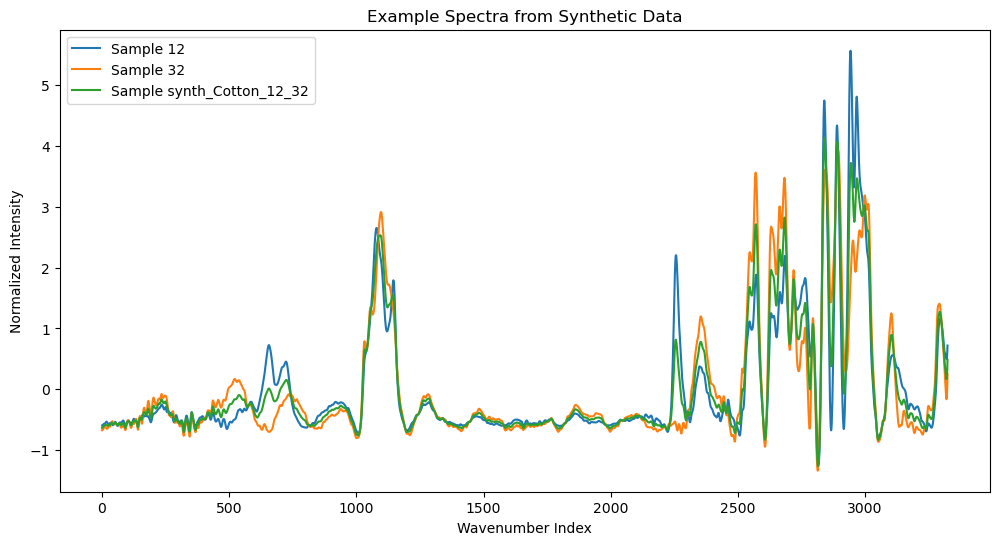

In [143]:
plt.figure(figsize=(12, 6))
# plot spectra with indices 0, 4, 160
for idx in ['12', '32', 'synth_Cotton_12_32']:
    spectrum = cotton_synthetic[cotton_synthetic['Spectrum_ID'] == idx].iloc[0, 2:].values.astype(float)
    plt.plot(spectrum, label=f'Sample {idx}')
plt.title('Example Spectra from Synthetic Data')
plt.xlabel('Wavenumber Index')
plt.ylabel('Normalized Intensity')
plt.legend()

### Mixed synthetic data

In [136]:
def make_synthetic_data_mixed(df, new_samples_per_class_mix=100, mix_lower_bound=0.1, mix_upper_bound=0.9):
    """
    Makes synthetic data by taking linear combinations (Mixup) of spectra 
    in different textile classes (all possible combinations).
    
    Parameters:
    - df: The original data (just put final_df frfr)
    - new_samples_per_class_mix: how much data we make per possible class mix
    - mix_lower_bound: Float (0.0 to 1.0), lower bound for the mixing %
    - mix_upper_bound: Float (0.0 to 1.0), upper bound for the mixing %

    Returns:
    - A df with original and synthetic data.
    """
    synthetic_rows = []
    classes = df['Labels'].unique()

    class_mixes = list(combinations(classes, 2))

    for cls1, cls2 in class_mixes:
        subset1 = df[df['Labels'] == cls1].reset_index(drop=True)
        subset2 = df[df['Labels'] == cls2].reset_index(drop=True)

        mixed_label = f"{cls1}_{cls2}"

        for _ in range(new_samples_per_class_mix):
            idx1 = np.random.choice(subset1.index)
            idx2 = np.random.choice(subset2.index)
            
            sample1 = subset1.loc[idx1]
            sample2 = subset2.loc[idx2]

            alpha_sample = np.random.uniform(mix_lower_bound, mix_upper_bound)

            pure_spectrum1 = sample1.drop(['Spectrum_ID', 'Labels'])
            pure_spectrum2 = sample2.drop(['Spectrum_ID', 'Labels'])

            blended_spectrum = alpha_sample * pure_spectrum1 + (1 - alpha_sample) * pure_spectrum2

            spectrum1_id_true = subset1.loc[idx1, 'Spectrum_ID']
            spectrum2_id_true = subset2.loc[idx2, 'Spectrum_ID']

            synthetic_row = {
                'Spectrum_ID': f'synth_{cls1}_{spectrum1_id_true}_{cls2}_{spectrum2_id_true}',
                'Labels': f'{cls1}_{alpha_sample:.2f}_{cls2}_{1-alpha_sample:.2f}'
            }
            synthetic_row.update(blended_spectrum.to_dict())
            synthetic_rows.append(synthetic_row)

    synthetic_df = pd.DataFrame(synthetic_rows)
    combined_df = pd.concat([df, synthetic_df], ignore_index=True)
    return combined_df

In [137]:
synthetic_mixed_df = make_synthetic_data_mixed(final_df, new_samples_per_class_mix=1000, mix_lower_bound=0.5, mix_upper_bound=0.75)
print(synthetic_mixed_df.shape)
synthetic_mixed_df

(21306, 3327)


,Spectrum_ID,Labels,3999.0,3998.0,3997.0,3996.0,3995.0,3994.0,3993.0,3992.0,...,684.0,683.0,682.0,681.0,680.0,679.0,678.0,677.0,676.0,675.0
0,25,Cotton,-0.589431,-0.583491,-0.585809,-0.593964,-0.605536,-0.617946,-0.627697,-0.633485,...,-0.001050,-0.014039,-0.043559,-0.090381,-0.154960,-0.242933,-0.350740,-0.477703,-0.623266,-0.786871
1,26,Cotton,-0.554183,-0.541143,-0.533607,-0.530690,-0.531509,-0.535060,-0.540494,-0.546764,...,0.519866,0.494692,0.438794,0.344631,0.200871,-0.001833,-0.260377,-0.565495,-0.912743,-1.297676
2,27,Cotton,-0.576121,-0.576430,-0.576432,-0.575790,-0.574169,-0.570710,-0.565197,-0.558863,...,-0.447825,-0.420701,-0.392673,-0.363106,-0.332719,-0.305207,-0.279574,-0.261360,-0.253823,-0.260220
3,28,Cotton,-0.601464,-0.594101,-0.591870,-0.593198,-0.596515,-0.599431,-0.601514,-0.600325,...,0.021621,0.025172,0.003112,-0.046516,-0.121213,-0.225664,-0.354369,-0.499100,-0.654319,-0.814492
4,29,Cotton,-0.596008,-0.582916,-0.574488,-0.570278,-0.569844,-0.573096,-0.579014,-0.587144,...,0.054210,0.056583,0.041850,0.004182,-0.060275,-0.150235,-0.262368,-0.383451,-0.505433,-0.620266
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21301,synth_Silk_126_Wool_146,Silk_0.66_Wool_0.34,-0.561711,-0.562006,-0.559664,-0.555766,-0.551396,-0.548384,-0.547394,-0.547589,...,-0.422397,-0.391839,-0.355501,-0.321114,-0.294099,-0.274542,-0.260882,-0.245654,-0.224686,-0.193809
21302,synth_Silk_16_Wool_151,Silk_0.58_Wool_0.42,-0.426355,-0.417428,-0.418662,-0.428864,-0.446839,-0.471767,-0.502901,-0.537651,...,-0.113555,-0.160235,-0.205990,-0.249595,-0.293094,-0.339147,-0.384233,-0.432629,-0.486268,-0.547079
21303,synth_Silk_131_Wool_11,Silk_0.73_Wool_0.27,-0.628253,-0.632112,-0.632215,-0.630043,-0.627076,-0.625144,-0.626390,-0.630548,...,-0.584470,-0.590043,-0.591391,-0.584770,-0.572693,-0.562430,-0.549504,-0.536745,-0.525461,-0.516958
21304,synth_Silk_1_Wool_142,Silk_0.65_Wool_0.35,-0.608293,-0.602594,-0.598040,-0.594459,-0.591679,-0.589075,-0.587078,-0.586442,...,0.048364,-0.021787,-0.062169,-0.073035,-0.062219,-0.045665,-0.040860,-0.067096,-0.141491,-0.281160
